As AI scales, so does its energy footprint. [Johan Suykens](https://www.esat.kuleuven.be/sista/members/suykens.html), creator of Least Squares Support Vector Machines (LS-SVM), has spent decades exploring how kernel methods can yield elegant, compact solutions. His 2016 paper ["SVD revisited"](https://www.sciencedirect.com/science/article/pii/S1063520315001360) reformulates SVD through a variational principle that reveals deep structure. A structure that connects directly to attention mechanisms in transformers. The recent [Primal-Attention](https://arxiv.org/abs/2305.19798) paper follows this thread, showing how kernel SVD enables equivalent performance with far more compact networks. This isn't optimization for its own sake; it's a path toward sustainable AI.

These papers are technically demanding and assume significant background. My goal is to smooth the learning curve, to reveal the beauty and insight of this framework, and why it matters for the future of AI.

**This is a three part series:**

1. **Part 1 (this post)**: Rebuild SVD from geometry to its classical variational formulation
2. **Part 2**: Suykens' LS-SVM reformulation and kernel SVD (covering "SVD revisited")
3. **Part 3**: From kernel SVD to attention mechanisms (covering "Primal-Attention")

We start by asking: **what does a matrix do to space**? Most ML engineers know SVD as `u, s, v = torch.linalg.svd(A)`, but the geometric intuition fades. For square matrices, eigenvalues answer this. For rectangular matrices, they can't. So we exhibit the four fundamental subspaces, revealing that **singular vectors are maximally coupled** through the matrix. We then show how the classical variational formulation, a different perspective, arrives at the same solution.

**Our audience**: ML/AI practitioners who want geometric intuition alongside rigor. Proofs where they illuminate, code where it grounds abstraction.

# From Eigenvalues to SVD

**What does a matrix actually do?** This question drives everything that follows. In machine learning, matrices aren't abstract objects, they encode data (`m` samples as rows, `n` features as columns) or transformations we want to understand. When we ask "what does this matrix do?", we're asking: how does it stretch, rotate, or compress what we put through it? Can we summarize that action simply?

For square matrices, eigenvalues and eigenvectors answer this beautifully. But most data matrices aren't square. The question remains valid; the tool fails. SVD emerges as the natural replacement: instead of one set of special directions, we get two: one for the input space, one for the output, linked through singular values. This "find the essence" theme will reappear when we reformulate SVD variationally.

::: {.callout-note collapse="true"}
## Linear Algebra Prerequisites

This post assumes familiarity with eigenvalues, eigenvectors, and matrix factorizations. If you need a refresher:

- **For intuition**: Grant Sanderson's [Essence of Linear Algebra](https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) builds geometric understanding from first principles

- **For depth**: Gilbert Strang's [MIT 18.06 Linear Algebra](https://www.youtube.com/watch?v=QVKj3LADCnA&list=PL49CF3715CB9EF31D) remains the gold standard for rigorous yet accessible treatment

:::

## Eigenvalues and Eigenvectors

For a square matrix, eigenvalues and eigenvectors capture its essence. An eigenvector $v$ satisfies $Av = \lambda v$: the matrix acts on it by pure scaling. The eigenvalue $\lambda$ tells the story:

- $\lambda > 0$: stretch along $v$
- $\lambda < 0$: stretch and flip
- $|\lambda| > 1$: expansion; $|\lambda| < 1$: contraction
- $\lambda = 0$: collapse to zero
- Complex $\lambda$: rotation and scaling combined

A matrix can look complicated, but its eigenvalues summarize what it fundamentally does to space.

### Visualizing the Transformation

Let's see this in action with a concrete example:

$$A = \begin{bmatrix} 3 & 1 \\ 2 & 2 \end{bmatrix}$$

What does this matrix actually do? Each column of $A$ tells us where a standard basis vector lands: $e_1 = [1,0]$ maps to $Ae_1 = [3,2]$, and $e_2 = [0,1]$ maps to $Ae_2 = [1,2]$. But this doesn't reveal the structure.

To see the essence, pass a unit circle through $A$. Every point on the circle is a unit vector; its image shows how $A$ stretches and rotates space. The circle becomes an ellipse. The eigenvectors point in directions where $A$ acts by pure scaling, with no rotation. Along $v_1$, space stretches by $\lambda_1 = 4$. Along $v_2$, it stretches by $\lambda_2 = 1$.


::: {.callout-note collapse="true"}
## Are Eigenvectors perpendicular?
For general square matrices, eigenvectors aren't necessarily perpendicular. The exception: symmetric matrices, whose eigenvectors are always orthogonal. **Covariance matrices, which appear constantly in ML, are symmetric** with non-negative eigenvalues making them positive semidefinite (positive definite when full rank).
:::

Computing eigenvalues by hand means solving $\det(A - \lambda I) = 0$, which gets tedious fast. In practice, we let NumPy handle it:

In [45]:
import numpy as np
A = np.array([[3, 1], 
              [2, 2]])  # Non-symmetric: eigenvectors won't be orthogonal
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

Eigenvalues: [4. 1.]
Eigenvectors:
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]


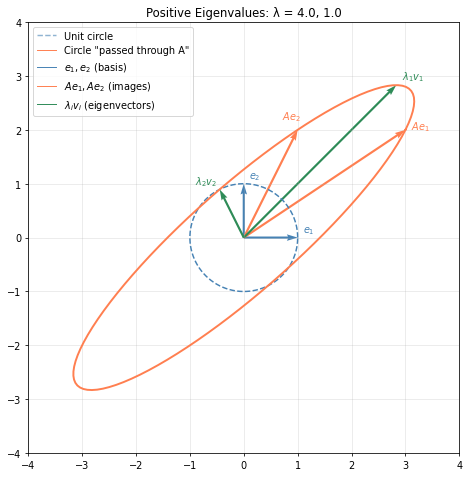

In [ ]:
#| echo: false
#| fig-align: center
#| label: eigen-decomposition
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 70
width = 0.005

# Unit circle
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])

# Transform circle
ellipse = A @ circle

# Standard basis vectors
e1, e2 = np.array([1, 0]), np.array([0, 1])
Ae1, Ae2 = A @ e1, A @ e2

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(circle[0], circle[1], color='steelblue', linestyle='--', alpha=1)
ax.plot(ellipse[0], ellipse[1], color='coral', linewidth=2, label='Circle "passed through A"')
# Standard basis vectors
ax.quiver(0, 0, e1[0], e1[1], angles='xy', scale_units='xy', scale=1, 
          color='steelblue', width=width, label=r'$e_1, e_2$ (basis)')
ax.quiver(0, 0, e2[0], e2[1], angles='xy', scale_units='xy', scale=1, 
          color='steelblue', width=width)

# Their images under A
ax.quiver(0, 0, Ae1[0], Ae1[1], angles='xy', scale_units='xy', scale=1, 
          color='coral', width=width, label=r'$Ae_1, Ae_2$ (images)')
ax.quiver(0, 0, Ae2[0], Ae2[1], angles='xy', scale_units='xy', scale=1, 
          color='coral', width=width)

# Eigenvectors (scaled by eigenvalues)
ev1 = eigenvectors[:, 0] * eigenvalues[0]
ev2 = eigenvectors[:, 1] * eigenvalues[1]
ax.quiver(0, 0, ev1[0], ev1[1], angles='xy', scale_units='xy', scale=1, 
          color='seagreen', width=width, label=r'$\lambda_i v_i$ (eigenvectors)')
ax.quiver(0, 0, ev2[0], ev2[1], angles='xy', scale_units='xy', scale=1, 
          color='seagreen', width=width)

# Text annotations
ax.text(e1[0]+0.1, e1[1]+0.1, r'$e_1$', fontsize=10, color='steelblue')
ax.text(e2[0]+0.1, e2[1]+0.1, r'$e_2$', fontsize=10, color='steelblue')
ax.text(Ae1[0]+0.1, Ae1[1]+0, r'$Ae_1$', fontsize=10, color='coral')
ax.text(Ae2[0]-0.3, Ae2[1]+0.2, r'$Ae_2$', fontsize=10, color='coral')
ax.text(ev1[0]+0.1, ev1[1]+0.1, r'$\lambda_1 v_1$', fontsize=10, color='seagreen')
ax.text(ev2[0]-0.45, ev2[1]+0.1, r'$\lambda_2 v_2$', fontsize=10, color='seagreen')

ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3); ax.legend()
ax.set_title(f'Positive Eigenvalues: λ = {eigenvalues[0]:.1f}, {eigenvalues[1]:.1f}')
#plt.legend(handlelength=3, handleheight=0.1)
#plt.legend(handleheight=0.1)
legend_elements = [
    plt.Line2D([0], [0], color='steelblue', linestyle='--', alpha=0.6, label='Unit circle'),
    plt.Line2D([0], [0], color='coral', linewidth=1, label='Circle "passed through A"'),
    plt.Line2D([0], [0], color='steelblue', linewidth=1, label=r'$e_1, e_2$ (basis)'),
    plt.Line2D([0], [0], color='coral', linewidth=1, label=r'$Ae_1, Ae_2$ (images)'),
    plt.Line2D([0], [0], color='seagreen', linewidth=1, label=r'$\lambda_i v_i$ (eigenvectors)'),
]
ax.legend(handles=legend_elements)

plt.show()

This eigenvalue story is elegant for square matrices. But recall our opening question: most data matrices are rectangular: `m` samples as rows, `n` features as columns. When we ask "what does this matrix do?" for real data, we need an answer that works beyond the square case.

## When Eigenvalues Fail

Now consider a 2×3 matrix (perhaps two measurements across three sensors, or two data points with three features):

$$A = \begin{bmatrix} 1 & 2 & 0 \\ 0 & 1 & 2 \end{bmatrix}$$

Can we compute eigenvalues? The eigenvalue equation $Av = \lambda v$ requires that $v$ and $Av$ live in the same space: we subtract them to get $(A - \lambda I)v = 0$. But here $v \in \mathbb{R}^3$ and $Av \in \mathbb{R}^2$. The dimensions don't match. There is no identity matrix $I$ that makes $A - \lambda I$ meaningful.

Eigenvalues are fundamentally about a matrix acting on a space and returning to that same-dimensional space. Rectangular matrices map between spaces of different dimensions. We need a different tool.

## The Four Subspaces of a Matrix

::: {.callout-note collapse="false"}
## Quick dimension check
For a $2 \times 3$ matrix $A$, the input vector $x$ must be in $\mathbb{R}^3$ and the output $Ax$ lands in $\mathbb{R}^2$:

$$\underbrace{A}_{2 \times 3} \cdot \underbrace{x}_{3 \times 1} = \underbrace{Ax}_{2 \times 1}$$

```
    A         x       Ax
 ┌─────┐    ┌─┐     ┌─┐
 │     │    │ │     │ │
 │ 2×3 │  × │3│  =  │2│
 │     │    │ │     │ │
 └─────┘    └─┘     └─┘
   ↑          ↑       ↑
 (rows×cols) (R³)    (R²)
```

The "inner" dimensions must match (3 = 3), and the "outer" dimensions give the result shape.

:::

Consider again our 2×3 matrix $A$. It takes 3D vectors as input and produces 2D vectors as output. We're squashing 3D down to 2D. Something must get lost.

**Where do the inputs live?**

Look at the rows of $A$: they are two vectors in $\mathbb{R}^3$:
- Row 1: $(1, 2, 0)$
- Row 2: $(0, 1, 2)$

These two vectors span a plane in 3D. This plane is the **row space** as shown in @fig-decomposition

Now imagine feeding a 3D vector $x$ into $A$. Three things can happen:

1. **$x$ lies in the row space plane**: it maps to something nonzero in $\mathbb{R}^2$
2. **$x$ is perpendicular to that plane**: it gets killed, $Ax = 0$
3. **$x$ is tilted away from the plane**: it splits into two parts. The part in the plane survives; the part perpendicular to it vanishes (the situation we are portraying in @fig-decomposition)

The perpendicular direction (and anything along it) is the **null space**.

**The decomposition**

As shown in @fig-decomposition, any input vector $x \in \mathbb{R}^3$ splits uniquely into two orthogonal pieces:

$$x = x_{\text{row}} + x_{\text{null}}$$

When $A$ acts:

- $Ax_{\text{row}}$ → lands in the column space (nonzero)
- $Ax_{\text{null}}$ → vanishes to zero

So $Ax = Ax_{\text{row}}$. The null space component is silently erased. Only the row space projection determines the output. This is why information is "lost" when we squash dimensions; vectors that differ only in their null space component become indistinguishable after multiplication.

::: {.callout-note collapse="true"}
## Rank of a matrix
The dimension of the row space is called the **rank** of the matrix (here, rank 2). A fundamental theorem: row space and column space always share the same dimension. And notice: rank + dim(null space) = 3 (the input dimension). Our 2×3 matrix has rank 2, so the null space is 1 dimensional (exactly one direction gets erased).
:::


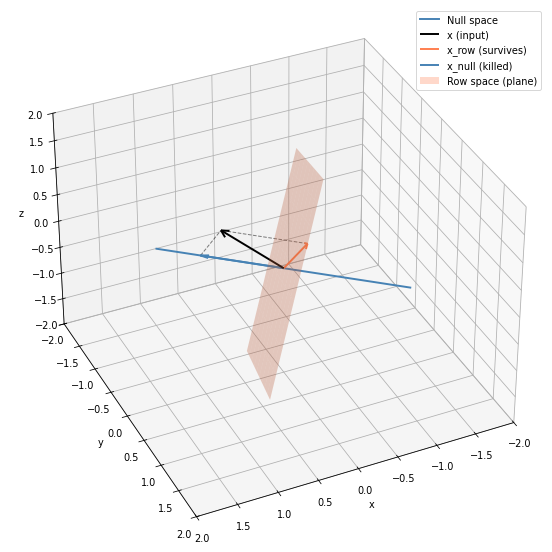

In [47]:
#| echo: false
#| fig-align: center
#| label: fig-decomposition
#| fig-cap: "Input space decomposition"
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
row_space_proxy = Patch(facecolor='coral', alpha=0.3, label='Row space (plane)')

A = np.array([[1, 2, 0],
              [0, 1, 2]])

# Get SVD to find row space and null space bases
U, s, Vt = np.linalg.svd(A)
V = Vt.T

# Row space: first 2 columns of V (nonzero singular values)
# Null space: last column of V (zero singular value)
v_row1, v_row2 = V[:, 0], V[:, 1]
v_null = V[:, 2]

# Pick a test vector tilted away from the row space
x = np.array([1.0, 0.5, 1.5])

# Decompose x into row space and null space components
x_null = np.dot(x, v_null) * v_null
x_row = x - x_null

# Plotting
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Draw the row space plane
t = np.linspace(-1.5, 1.5, 10)
T1, T2 = np.meshgrid(t, t)
plane_x = T1 * v_row1[0] + T2 * v_row2[0]
plane_y = T1 * v_row1[1] + T2 * v_row2[1]
plane_z = T1 * v_row1[2] + T2 * v_row2[2]
ax.plot_surface(plane_x, plane_y, plane_z, alpha=0.3, color='coral')

# Null space direction (extended line)
null_line = np.linspace(-1.5, 1.5, 20)
ax.plot(null_line*v_null[0], null_line*v_null[1], null_line*v_null[2], 
        'steelblue', linewidth=2, label='Null space')

# Original vector x
ax.quiver(0, 0, 0, x[0], x[1], x[2], color='black', linewidth=2, 
          arrow_length_ratio=0.1, label='x (input)')

# Row space component
ax.quiver(0, 0, 0, x_row[0], x_row[1], x_row[2], color='coral', linewidth=2,
          arrow_length_ratio=0.1, label='x_row (survives)')

# Null space component  
ax.quiver(0, 0, 0, x_null[0], x_null[1], x_null[2], color='steelblue', linewidth=2,
          arrow_length_ratio=0.1, label='x_null (killed)')

# Dashed lines showing decomposition
ax.plot([x_row[0], x[0]], [x_row[1], x[1]], [x_row[2], x[2]], 
        'k--', alpha=0.5, linewidth=1)
ax.plot([x_null[0], x[0]], [x_null[1], x[1]], [x_null[2], x[2]], 
        'k--', alpha=0.5, linewidth=1)

ax.view_init(elev=35, azim=65)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='coral', alpha=0.3))
labels.append('Row space (plane)')
ax.legend(handles, labels)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_zlim(-2, 2)
plt.tight_layout()
plt.show()

**The output side**

We've seen two of the four subspaces: the row space (directions that survive) and the null space (directions that get killed). Both live in the input space $\mathbb{R}^n$.

Now for the other two. Think of $A$ as a linear map from $\mathbb{R}^n$ to $\mathbb{R}^m$. Its transpose $A^T$ goes the other way: from $\mathbb{R}^m$ back to $\mathbb{R}^n$. The remaining two subspaces come from asking the same questions about $A^T$ that we asked about $A$:

- **Column space**: where $A$ can actually send vectors (the "row space" of $A^T$)
- **Left null space**: directions in the output that $A$ can never reach (the "null space" of $A^T$)

For our 2×3 matrix, the column space fills all of $\mathbb{R}^2$, every output point is reachable. So there's no left null space.

But imagine we had a 3×2 matrix instead (expanding 2D → 3D). Now the roles flip:
- Every input direction is used (no null space)
- The matrix maps all of $\mathbb{R}^2$ to a plane in $\mathbb{R}^3$ (still rank 2), but not every vector in $\mathbb{R}^3$ is reachable, the direction perpendicular to this plane is the left null space

The symmetry: what the null space is to $A$, the left null space is to $A^T$.

**The Four Fundamental Subspaces: A Summary**

| Space | Lives in | What it represents |
|-------|----------|-------------------|
| Row space | Input $\mathbb{R}^n$ | Directions that produce output |
| Null space | Input $\mathbb{R}^n$ | Directions that get killed |
| Column space | Output $\mathbb{R}^m$ | Where outputs land |
| Left null space | Output $\mathbb{R}^m$ | Directions never reached |

The matrix creates a perfect one-to-one map between row space and column space. The null spaces are the "leftovers", killed on input, unreachable on output.

### Finding the Four Subspaces

We've seen the geometry: four subspaces, with $A$ creating a perfect map between row space and column space. But how do we actually *find* orthonormal bases for these subspaces?

The trick: form two square, symmetric matrices:
- $A^TA$ (lives in input space $\mathbb{R}^n$) captures how columns correlate
- $AA^T$ (lives in output space $\mathbb{R}^m$) captures how rows correlate

For our matrix $A$, these are:

$$A^TA = \begin{bmatrix} 1 & 2 & 0 \\ 2 & 5 & 2 \\ 0 & 2 & 4 \end{bmatrix}, \quad AA^T = \begin{bmatrix} 5 & 2 \\ 2 & 5 \end{bmatrix}$$


Both are symmetric, so they have orthogonal eigenvectors. And the beautiful fact: these eigenvectors partition exactly into our four subspaces.

| Matrix | Eigenvectors with $\lambda > 0$ | Eigenvectors with $\lambda = 0$ |
|--------|--------------------------------|--------------------------------|
| $A^TA$ | Row space | Null space |
| $AA^T$ | Column space | Left null space |

Let's verify this connection numerically. We'll compute the eigendecompositions of $A^TA$ and $AA^T$, then compare their eigenvectors with what SVD produces directly:

In [48]:
# Eigendecompositions
eig_vals_ATA, eig_vecs_ATA = np.linalg.eig(A.T @ A)
eig_vals_AAT, eig_vecs_AAT = np.linalg.eig(A @ A.T)

# Sort by eigenvalues (descending) to match SVD ordering
idx_ATA = np.argsort(eig_vals_ATA)[::-1]
idx_AAT = np.argsort(eig_vals_AAT)[::-1]
V_from_eig = eig_vecs_ATA[:, idx_ATA]
U_from_eig = eig_vecs_AAT[:, idx_AAT]
sigma_sq = np.sort(eig_vals_ATA)[::-1][:2]  # nonzero eigenvalues

# Compare with SVD
U, sigma, Vt = np.linalg.svd(A)

print("Eigenvalues (σ²):", sigma_sq)
print("Singular values squared:", sigma**2)
print("\nU matches (up to sign)?", np.allclose(np.abs(U_from_eig), np.abs(U)))
print("V matches (up to sign)?", np.allclose(np.abs(V_from_eig), np.abs(Vt.T)))

Eigenvalues (σ²): [7. 3.]
Singular values squared: [7. 3.]

U matches (up to sign)? True
V matches (up to sign)? True


::: {.callout-note collapse="true"}
## Why does this work?

**The null space connection**: If $v$ is in the null space, then $Av = 0$, so $A^TAv = 0$, meaning $v$ is an eigenvector of $A^TA$ with eigenvalue zero.

**The row space connection**: Symmetric matrices have orthogonal eigenvectors (see Strang's course, or verify numerically). Since $A^TA$ is $n \times n$ and symmetric, its eigenvectors form an orthonormal basis for all of $\mathbb{R}^n$. We just showed the null space eigenvectors have $\lambda = 0$. The remaining eigenvectors (with $\lambda > 0$) must be orthogonal to them. But we also know the row space and null space are orthogonal complements in $\mathbb{R}^n$. So these remaining eigenvectors span exactly the row space.

The same logic applies to $AA^T$ on the output side: zero eigenvalue eigenvectors give the left null space, and the rest give the column space.

*This is geometric intuition, not a formal proof, but it shows why the eigendecompositions naturally reveal our four subspaces.*
:::

## SVD: Finding structure in both spaces

We already computed the SVD above when verifying the eigendecomposition connection. Let's examine what it returned: orthonormal bases for the input and output spaces, linked through the singular values.

In [49]:
print(f"Singular values: {sigma}")
print(f"\nV (right singular vectors — input space):\n{Vt.T}")
print(f"\nU (left singular vectors — output space):\n{U}")

Singular values: [2.64575131 1.73205081]

V (right singular vectors — input space):
[[-0.26726124 -0.40824829  0.87287156]
 [-0.80178373 -0.40824829 -0.43643578]
 [-0.53452248  0.81649658  0.21821789]]

U (left singular vectors — output space):
[[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]


The SVD returns two singular values: $\sigma_1 \approx 2.65$ and $\sigma_2 \approx 1.73$. Why only two? For an $m \times n$ matrix, you get at most $\min(m, n)$ nonzero singular values (here, $\min(2, 3) = 2$). Since both rows of $A$ are linearly independent (rank 2), we get exactly two positive values. The "missing" third direction in $\mathbb{R}^3$ is the null space; it gets killed by $A$, contributing nothing to the output. The matrices $U$ and $V$ contain orthonormal vectors: `U.T @ U` and `Vt @ Vt.T` both yield the identity matrix, confirming that the singular vectors form orthonormal bases for the column space and row space respectively.

In [50]:
print("V^T @ V (should be I):\n", np.round(Vt @ Vt.T, 10))
print("\nU^T @ U (should be I):\n", np.round(U.T @ U, 10))

V^T @ V (should be I):
 [[ 1. -0.  0.]
 [-0.  1.  0.]
 [ 0.  0.  1.]]

U^T @ U (should be I):
 [[ 1. -0.]
 [-0.  1.]]


### The geometry of SVD

The SVD reveals that *any* matrix can be decomposed into three simple operations:

$$A = U \Sigma V^T$$

Geometrically: rotate ($V^T$) → stretch ($\Sigma$) → rotate ($U$)

Pass a unit circle through each step and watch it transform into an ellipse.

*Note: We use a 2×2 matrix here for visualization clarity. With our 2×3 example, the input space is 3D (making the "rotate → stretch → rotate" harder to show in 2D plots). The geometric principle is identical: SVD always decomposes a linear map into rotations and axis-aligned stretching, but square matrices let us see all three steps in the same plane.*

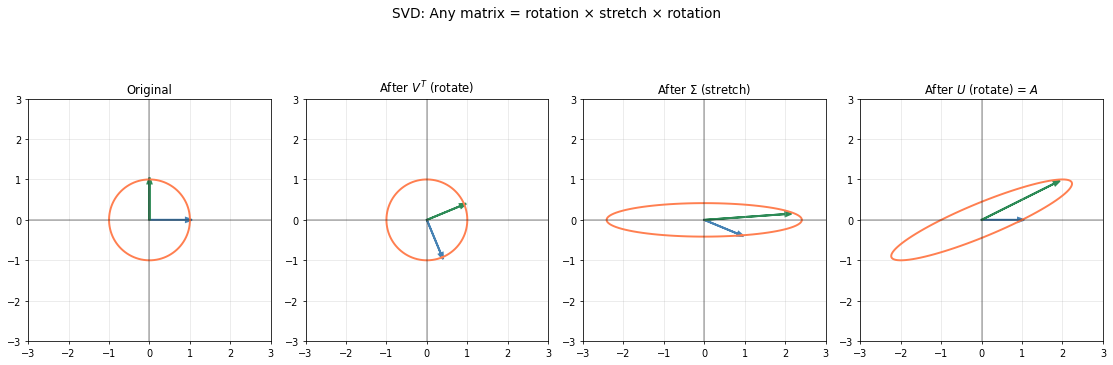

In [54]:
#| echo: false
#| fig-align: center
#| label: svd-factorization
import numpy as np
import matplotlib.pyplot as plt

# A 2x2 matrix for visualization
A = np.array([[1, 2],
              [0, 1]])

# SVD
U, s, Vt = np.linalg.svd(A)
Sigma = np.diag(s)

# Unit circle
theta = np.linspace(0, 2*np.pi, 100)
circle = np.array([np.cos(theta), np.sin(theta)])

# Basis vectors
e1, e2 = np.array([1, 0]), np.array([0, 1])

# Step by step transformation
step1 = Vt @ circle
step2 = Sigma @ step1
step3 = U @ step2

# Basis vectors through each step
basis = [np.array([e1, e2]).T,          # Original
         Vt @ np.array([e1, e2]).T,      # After V^T
         Sigma @ Vt @ np.array([e1, e2]).T,  # After Σ
         U @ Sigma @ Vt @ np.array([e1, e2]).T]  # After U

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

titles = ['Original', r'After $V^T$ (rotate)', r'After $\Sigma$ (stretch)', r'After $U$ (rotate) = $A$']
data_list = [circle, step1, step2, step3]

for ax, data, b, title in zip(axes, data_list, basis, titles):
    ax.plot(data[0], data[1], 'coral', linewidth=2)
    # Draw basis vectors
    ax.arrow(0, 0, b[0,0]*0.9, b[1,0]*0.9, head_width=0.1, color='steelblue', linewidth=2)
    ax.arrow(0, 0, b[0,1]*0.9, b[1,1]*0.9, head_width=0.1, color='seagreen', linewidth=2)
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5); ax.axvline(0, color='k', linewidth=0.5)
    ax.set_title(title, fontsize=12)

plt.suptitle(r'SVD: Any matrix = rotation × stretch × rotation', fontsize=14)
plt.tight_layout()
plt.show()

### What SVD Reveals

We've seen that SVD decomposes any matrix into rotations and axis-aligned stretching. The singular values tell us *how much* the matrix stretches along each principal direction. Looking at the ellipse, the longest axis has length $\sigma_1$, the largest singular value.

This suggests a natural question: **can we characterize $\sigma_1$ directly as an optimization problem?** Among all unit vectors $v$, which one gets stretched the most by $A$, and by how much?

This viewpoint (finding special directions through optimization) leads to a **variational formulation** of SVD with a rich history (see [Stewart's 1993](https://epubs.siam.org/doi/10.1137/1035134) overview for early contributions). We'll derive SVD through this **classical variational principle** in the remainder of this post. In Parts 2 and 3, we'll see how Suykens' **LS-SVM reformulation** opens the door to kernel extensions and, ultimately, connections to attention mechanisms in transformers.

# The Variational Perspective

::: {.callout-note title="Variational Principle" collapse="true"}
A [variational Principle](https://www.sciencedirect.com/topics/physics-and-astronomy/variational-principle) reformulates a problem as: "find the object that maximizes (or minimizes) some quantity." Instead of solving equations directly, we search for extrema. This often reveals structure and enables new solution methods.
:::

## The Classical Variational Problem

SVD asks: which directions in input and output space are most strongly coupled through the matrix? We measure coupling strength with the bilinear form:

$$f(u, v) = u^T A v$$

where $u \in \mathbb{R}^m$ lives in output space and $v \in \mathbb{R}^n$ lives in input space.

*Why "bilinear"?* The function is linear in each argument separately: if you fix $v$ and vary $u$, you get a linear function of $u$; fix $u$ and vary $v$, linear in $v$. But it's not linear in both together: scaling both by 2 multiplies the output by 4, not 2.

### Reading the bilinear form geometrically

The expression $u^T A v$ has a natural interpretation: take a unit vector $v$ from input space, pass it through $A$ to get $Av$ in output space, then measure how aligned this output is with $u$ via the dot product $u^T(Av)$. Maximizing over both $u$ and $v$ means: find the input direction that, when transformed by $A$, can be most strongly aligned with some output direction. 

This connects to our earlier "maximum stretch" picture. When $u$ perfectly aligns with $Av$, the dot product equals $\|Av\|$ (since $\|u\|=1$). So maximizing coupling *is* finding maximum stretch, but now framed as a relationship between two spaces rather than a property of one.

### Why Constrain the Norms?

Without constraints, maximizing $u^T A v$ is trivial: just scale $u$ and $v$ to infinity. The coupling grows without bound, telling us nothing about the matrix's structure.

Fixing $\|u\| = \|v\| = 1$ removes this scaling freedom. Now we're asking a meaningful geometric question: among all unit vectors, which pair aligns most strongly through $A$? And what *is* this maximum value? We'll find out by solving the constrained optimization problem.

### Making it concrete

Let's see this variational formulation in action. We have our SVD of the 2×3 matrix $A$: the right singular vectors $v_1, v_2$ span the row space (a 2D plane in $\mathbb{R}^3$). 

Fix $u = u_1$ and parameterize $v = \cos(t) \cdot v_1 + \sin(t) \cdot v_2$. This traces a unit circle in that plane. At $t=0$ we're at $v_1$; at $t=\pi/2$ we're at $v_2$. What does the objective $u_1^T A v$ look like as we walk around this circle?

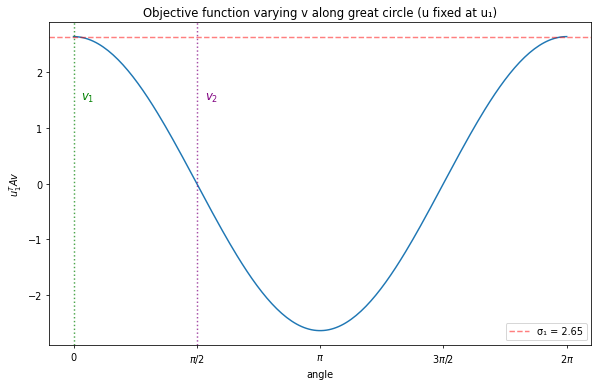

In [58]:
#| fig-align: center
A = np.array([[1, 2, 0],
              [0, 1, 2]])
U, sigma, Vt = np.linalg.svd(A)

# Extract singular vectors
v1, v2 = Vt[0], Vt[1]  # rows of Vt are the right singular vectors
u1, u2 = U[:, 0], U[:, 1]

# Parameterize great circle through v1 and v2
t = np.linspace(0, 2*np.pi, 200)
v_circle = np.array([np.cos(t_i) * v1 + np.sin(t_i) * v2 for t_i in t])

# Compute objective along this circle
objective = [u1 @ A @ v for v in v_circle]

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t, objective)
ax.set_xlabel('angle'); ax.set_ylabel(r'$u_1^T A v$')
ax.axhline(sigma[0], color='r', linestyle='--', alpha=0.5, label=f'σ₁ = {sigma[0]:.2f}')

ax.axvline(0, color='green', linestyle=':', alpha=0.7)
ax.axvline(np.pi/2, color='purple', linestyle=':', alpha=0.7)
ax.text(0.1, 1.5, r'$v_1$', color='green', fontsize=12)
ax.text(np.pi/2 + 0.1, 1.5, r'$v_2$', color='purple', fontsize=12)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

ax.legend()
ax.set_title('Objective function varying v along great circle (u fixed at u₁)')
plt.show()

At $v_1$, the objective reaches its maximum $\sigma_1 = 2.65$. The curve looks smooth and convex around this point (a nice local maximum). But wait: we also see a minimum at $t=\pi$ (which is just $-v_1$, giving $-\sigma_1$). And the curve passes through zero at $v_2$. 

This hints at something important: we're not looking at a single global optimum, but at *multiple* stationary points. The landscape has both maxima and minima. Why?"


### Why Multiple Solutions?

In convex optimization, life is simple: a bowl has one bottom, and gradient descent finds it. But our problem is doubly non-convex:

1. **The constraints aren't convex**: The unit sphere $\|u\| = 1$ isn't a convex set. Pick any two points on a circle and draw the line segment between them, it passes through the interior, not along the circle. A convex set must contain all such segments.

2. **The objective isn't convex**: The bilinear form $u^T A v$ curves upward in some directions and downward in others (a saddle, not a bowl).

So we won't find *the* optimum. Instead, we find *all* stationary points of the Lagrangian. The beautiful result: these stationary points are exactly the singular vector pairs $(u_i, v_i)$, with stationary values $\pm \sigma_i$. SVD emerges from solving for every extremum, not just one.

::: {.callout-note collapse="true"}
## Why isn't the bilinear form convex?

Consider the simplest bilinear form: $f(x, y) = xy$. To check convexity, we compute the Hessian (matrix of second derivatives):

$$H = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix} = \begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$$

For convexity, $H$ must be positive semidefinite (all eigenvalues $\geq 0$). For a 2×2 matrix, recall that:

- Trace = sum of eigenvalues: $\lambda_1 + \lambda_2 = 0 + 0 = 0$
- Determinant = product of eigenvalues: $\lambda_1 \lambda_2 = 0 \cdot 0 - 1 \cdot 1 = -1$

From $\lambda_1 + \lambda_2 = 0$ we get $\lambda_2 = -\lambda_1$. Substituting into $\lambda_1 \lambda_2 = -1$ gives $-\lambda_1^2 = -1$, so $\lambda_1 = \pm 1$. The eigenvalues are $\lambda = +1$ and $\lambda = -1$.

One positive, one negative: the Hessian is *indefinite*. This means $f(x,y) = xy$ is a saddle surface: curving upward in some directions, downward in others. Not convex, not concave.

*Intuition: $v^T H v$ gives the curvature (second derivative) in direction $v$. Positive definite means positive curvature in every direction (a bowl). Indefinite means some directions curve up, others down—a saddle.*


The general bilinear form $u^T A v$ inherits this structure. No matter what $A$ is, mixing input and output variables creates saddle geometry.
:::

::: {.callout-note collapse="false"}
## Constrained Optimization Prerequisites

We'll use Lagrange multipliers to solve constrained optimization. The core idea: move constraints into the objective function as penalty terms. Each constraint gets a multiplier representing the "price" for violating it. This converts a constrained problem into an unconstrained one we can solve with calculus.

If you need a refresher:

- **For intuition**: The [Visually Explained](https://www.youtube.com/watch?v=AM6BY4btj-M) series builds geometric understanding of convex optimization, Lagrangians, and KKT conditions

- **For depth**: Boyd & Vandenberghe's [Convex Optimization](https://stanford.edu/~boyd/cvxbook/) is the standard reference (free PDF available, and Boyd's Stanford lectures are online)

:::

::: {.callout-note collapse="true"}
## Derivatives with Respect to Vectors

The Lagrangian derivation requires differentiating with respect to vectors $u$ and $v$. If this is unfamiliar, Chieh Wu's [Derivatives with Respect to Vectors](https://www.youtube.com/watch?v=kzsW_pnqsFs&list=PLdk2fd27CQzQo1DEthJ5MDBHoC66_1aDN&index=2) provides a clear introduction.

For brevity here: think of $\|u\|^2 = u^T u$ as analogous to $x^2$ in single variable calculus, and $u^T A v$ as analogous to $xy$. The derivative of $x^2$ is $2x$; the derivative of $\|u\|^2$ with respect to $u$ is $2u$. Similarly, $\frac{\partial}{\partial u}(u^T A v) = Av$ (treating $v$ as constant). The rules follow the same intuition as polynomials of degree 2.
:::

### The Lagrangian Derivation

We want to find stationary points of:

$$\max_{u, v} \; u^T A v \quad \text{subject to} \quad \|u\|^2 = 1, \; \|v\|^2 = 1$$

Introduce multipliers $\lambda$ and $\mu$ for the two constraints:

$$\mathcal{L}(u, v, \lambda, \mu) = u^T A v - \frac{\lambda}{2}(\|u\|^2 - 1) - \frac{\mu}{2}(\|v\|^2 - 1)$$

Differentiate and set to zero:

$$\frac{\partial \mathcal{L}}{\partial u} = Av - \lambda u = 0 \quad \Rightarrow \quad Av = \lambda u$$

$$\frac{\partial \mathcal{L}}{\partial v} = A^T u - \mu v = 0 \quad \Rightarrow \quad A^T u = \mu v$$

Multiply the first equation by $u^T$: we get $u^T A v = \lambda$ (using $\|u\|^2 = 1$). Multiply the second by $v^T$: we get $v^T A^T u = \mu$. But $v^T A^T u = (u^T A v)^T = u^T A v$, so $\lambda = \mu$.

### The Shifted Eigenvalue Problem

With $\lambda = \mu$, stack the two conditions into a block matrix:

$$\begin{bmatrix} 0 & A \\ A^T & 0 \end{bmatrix} \begin{bmatrix} u \\ v \end{bmatrix} = \lambda \begin{bmatrix} u \\ v \end{bmatrix}$$

Why "shifted"? The diagonal blocks are zero: all the coupling lives in the off-diagonal blocks $A$ and $A^T$. The eigenvalues of this block matrix are exactly $\pm \sigma_1, \pm \sigma_2, \ldots, \pm \sigma_r$ (plus zeros if the matrix is rectangular), where $\sigma_i$ are the singular values of $A$.

### Recovering the SVD

From the shifted eigenvalue problem, we get $r$ pairs of eigenvectors $(u_i, v_i)$ with eigenvalues $\pm \sigma_i$. Stack the $u_i$ as columns of $U$, the $v_i$ as columns of $V$, and place $\sigma_i$ on the diagonal of $\Sigma$.

The stationarity conditions $Av_i = \sigma_i u_i$ become:

$$AV = U\Sigma$$

Multiply on the right by $V^T$:

$$A = U \Sigma V^T$$

The variational principle didn't just find singular vectors, it derived the entire factorization from "find maximally coupled directions."

Let's verify this: the eigenvalues of the block matrix should be exactly $\pm\sigma_i$ (plus a zero from the null space):

In [53]:
# Build the shifted block matrix
m, n = A.shape
block = np.block([[np.zeros((m, m)), A],
                  [A.T, np.zeros((n, n))]])

# Its eigenvalues should be ±σ and zeros
eigs = np.linalg.eigvalsh(block)
print("Block matrix eigenvalues:", np.sort(eigs)[::-1])
print("Singular values:", sigma)

Block matrix eigenvalues: [ 2.64575131e+00  1.73205081e+00 -1.55431223e-15 -1.73205081e+00
 -2.64575131e+00]
Singular values: [2.64575131 1.73205081]


The eigenvalues come in pairs $\pm\sigma_i$, confirming the theory. The value near $10^{-15}$ is numerically zero. This corresponds to the null space direction (our matrix has rank 2, but the block matrix is 5×5, so one eigenvalue must be zero).

This classical variational formulation isn't how we compute SVD in practice (direct algorithms are faster and more stable). But the formulation matters for what comes next: Suykens' LS-SVM reformulation rewrites this same variational principle in a way that admits kernelization, opening the door to nonlinear extensions and, ultimately, connections to attention mechanisms.

## Next: The LS-SVM Variational Reformulation

We've derived SVD from a variational principle: find maximally coupled directions between input and output space. The classical formulation is elegant, but it's locked to linear algebra with hard constraints on unit spheres and no obvious path to nonlinear extensions.

In **Part 2**, we'll see how Johan Suykens reformulates this same problem within the LS-SVM framework. The key insight: treat rows and columns of a matrix as *two data sources* with different feature maps. This seemingly small shift unlocks kernel methods and opens a door that leads, eventually, to the attention mechanism in transformers.
